In [1]:
from belt.belt_impact import run_belt, evaluate_belt
import h5py
import os
import numpy as np
# Nicer plotting

import matplotlib

%config InlineBackend.figure_format = 'retina'
matplotlib.rcParams["figure.figsize"] = (8, 4)

In [61]:
belt_config = {"input": "example1/belt.in", "workdir": os.environ.get("SCRATCH")}

In [68]:
SETTINGS0 = {
    "Impact_particles": "/sdf/data/ad/ard/u/jytang/lume-belt-live/impact_particles/final_particles.h5",
    "BC1:angle": np.float64(0.10093533481742675),
    "BC2:angle": np.float64(0.04682813787245896),
    "L1:gradient": np.float64(13174906.759592207),
    "L1:phase_deg": np.float64(-28.320456202149565),
    "L2:gradient": np.float64(15839664.067769654),
    "L2:phase_deg": np.float64(-22.586783950292368),
    "L3:gradient": np.float64(12261977.73214389),
    "L3:phase_deg": np.float64(0.0),
    "EBC1:energy_increment": -30e6,
    "EBC2:energy_increment": -30e6,
    "HL:gradient": np.float64(26885041.911759745),
    "HL:phase_deg": np.float64(-170.88668719344656),
}

In [69]:
E = run_belt(
    settings=SETTINGS0,
    belt_config=belt_config,
)

Shifting delta_e_over_e0 and delta_gamma given Ek


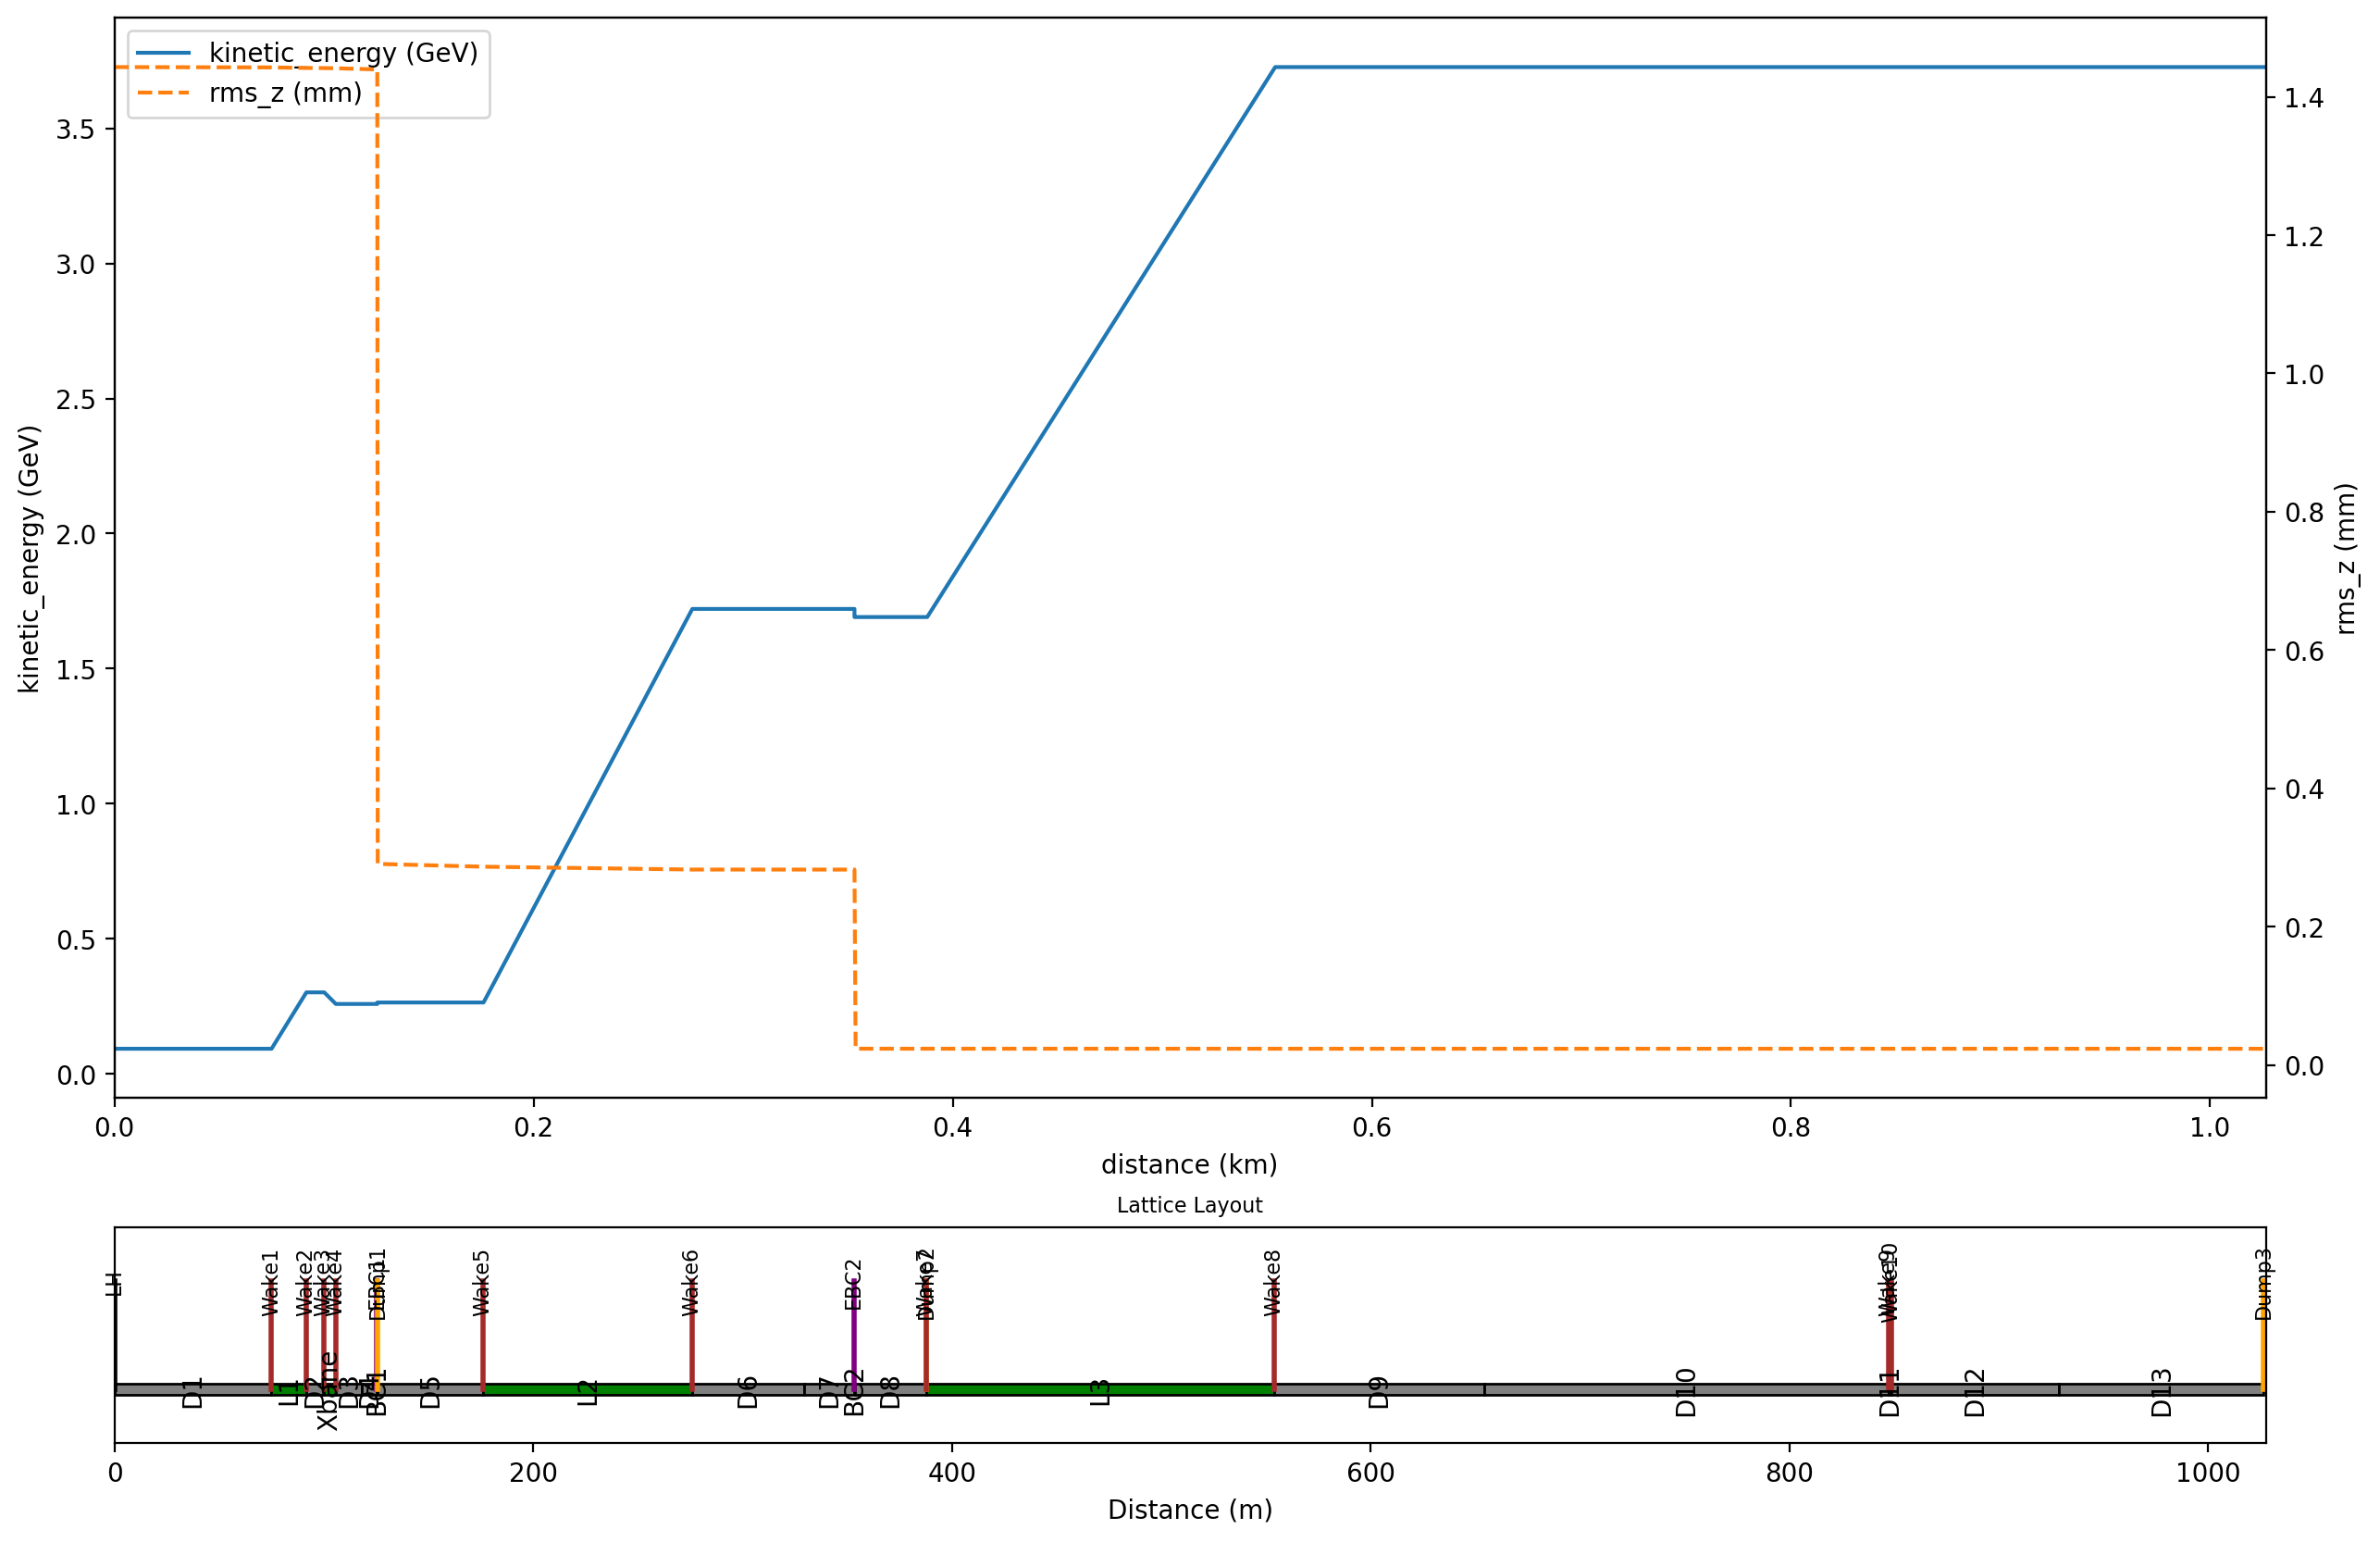

In [70]:
E.plot()

In [14]:
h5file = "./test.h5"
E.archive(h5file)

In [15]:
with h5py.File(h5file, "r") as h5:
    print(list(h5))

['input', 'output']


In [16]:
with h5py.File(h5file, "r") as h5:
    print(h5.keys())
    E.from_archive(h5)

<KeysViewHDF5 ['input', 'output']>


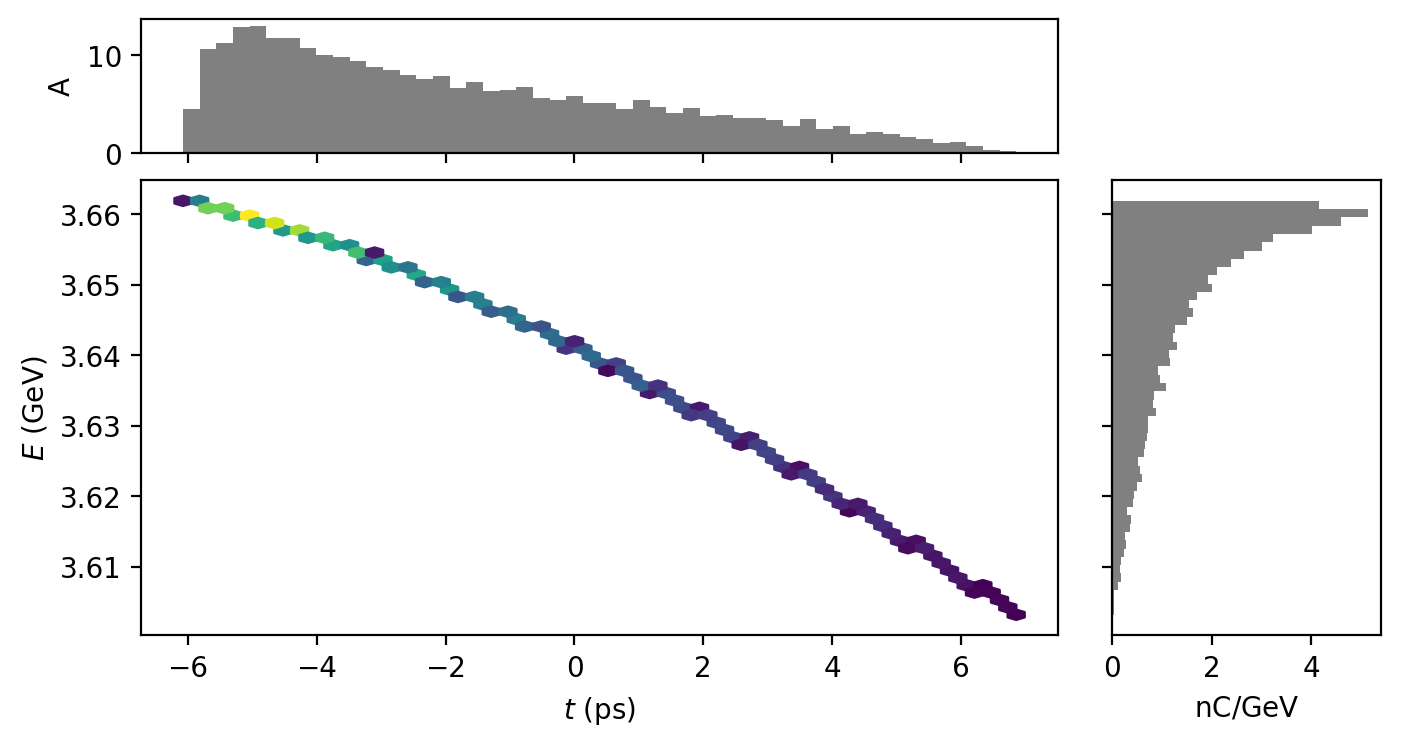

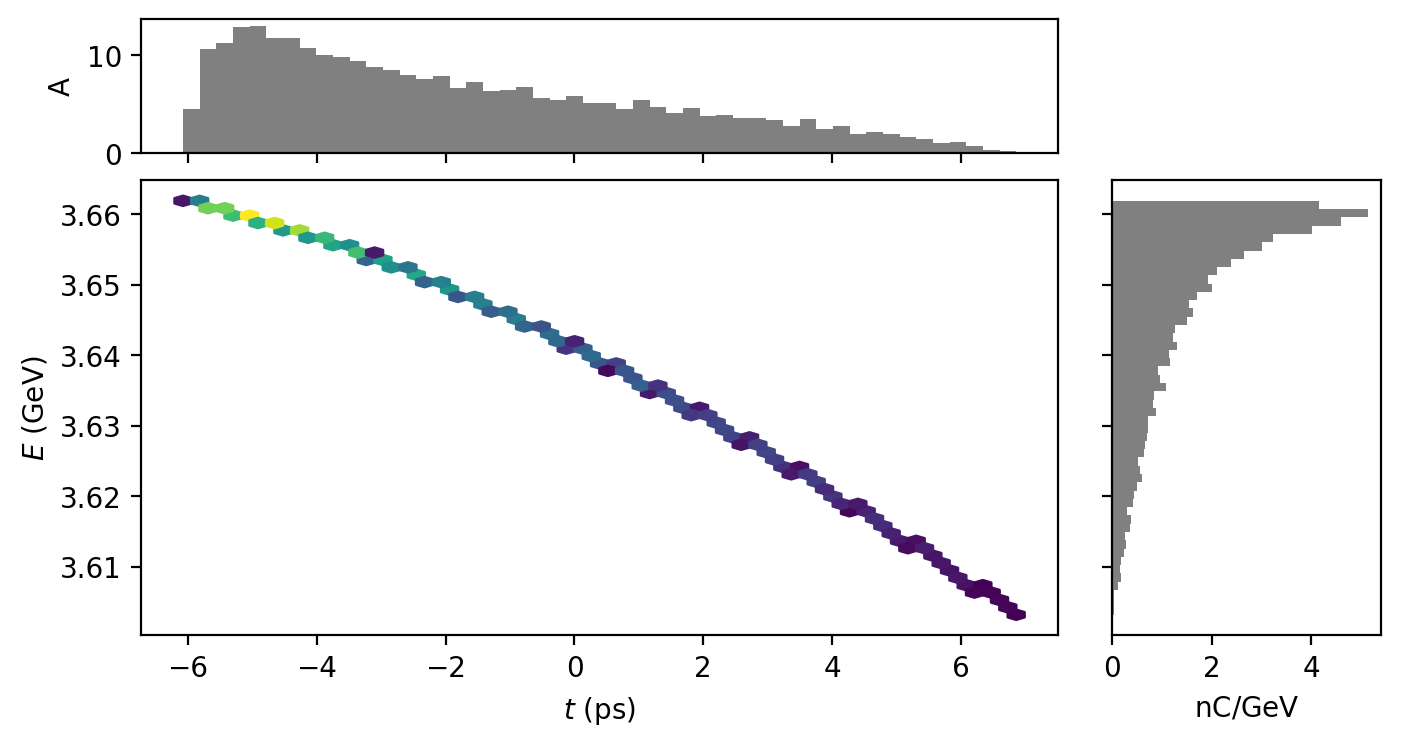

In [12]:
# Final particles
E.output.plot_distribution(file_id=201, xkey="t", ykey="energy")

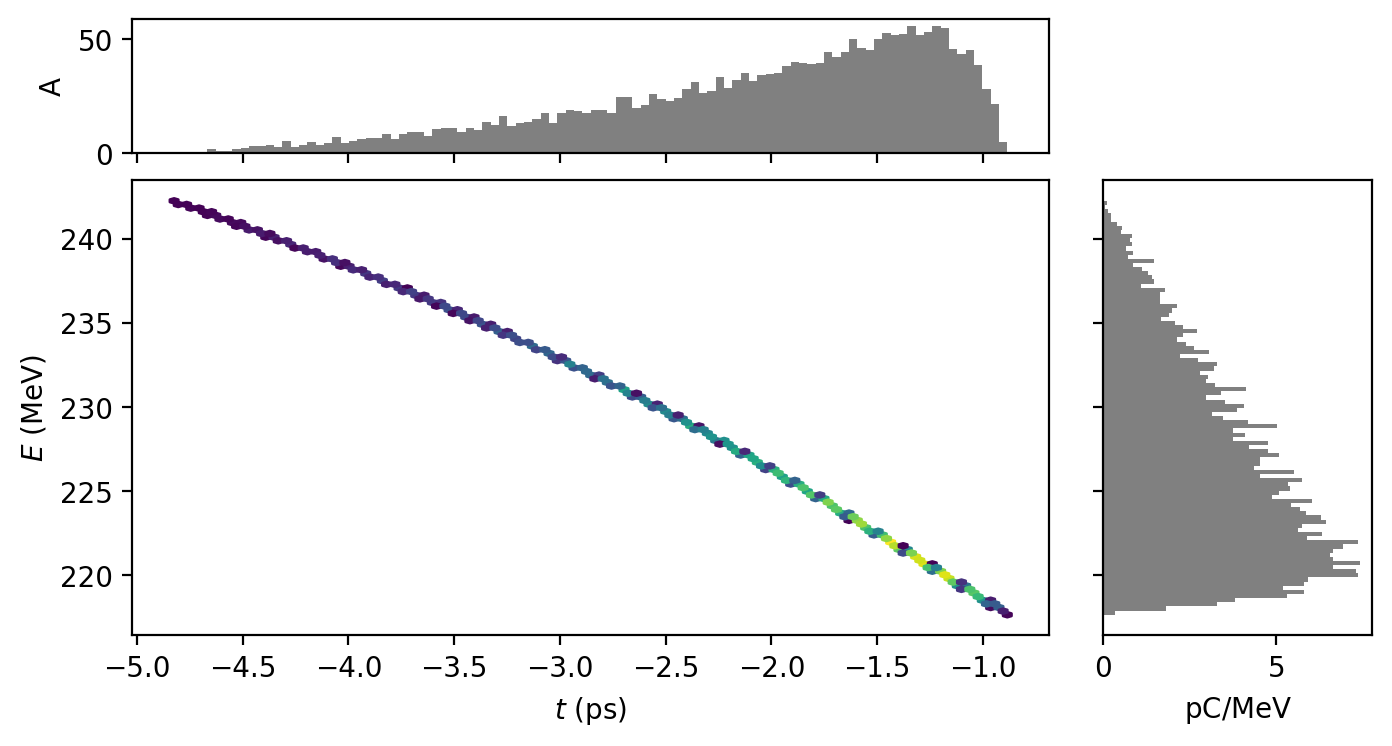

In [18]:
# After BC1
E.output.plot_distribution(file_id=211, xkey="t", ykey="energy")

In [20]:
# This returns an BELT object that has run
O1 = evaluate_belt(
    belt_config=belt_config,
    settings=SETTINGS0,
    archive_path=".",
)

# This is the default output
O1

Shifting delta_e_over_e0 and delta_gamma given Ek


{'error': False,
 'end_kinetic_energy': np.float64(4155053600.0),
 'end_gamma': np.float64(8132.1408),
 'end_mean_z': np.float64(-0.000374719253),
 'end_rms_z': np.float64(0.000105998297),
 'end_mean_delta_gamma': np.float64(11.5406736),
 'end_rms_delta_gamma': np.float64(17.4380186),
 'run_time': 0.7871285416185856,
 'end_n_particle_loss': 0,
 'end_total_charge': np.float64(8.624495615999999e-11),
 'end_higher_order_energy_spread': np.float64(530068.5474736947),
 'fingerprint': '55280400c169fc63f9eae9e4d9fd3ef5',
 'archive': '/sdf/data/ad/ard/u/jytang/lume-eblt/docs/examples/55280400c169fc63f9eae9e4d9fd3ef5.h5'}

In [2]:
-0.045 * 3 / 2

-0.0675